# Local code knowledge graph

This walkthrough builds a typed graph from a local Git repository, records reproducible repository provenance, retrieves relevant code with TF-IDF and graph expansion, and renders interactive Plotly views. The implementation lives in the `code_knowledge_graph` package so the notebook contains only configuration and analysis.

## Configure the target

Pass a repository path directly for automation. In an interactive session, `GraphConfig.resolve` checks `CODE_GRAPH_TARGET` and then an `implicit-decision-gate` directory beside this notebook repository. Use `mode="public"` or `mode="demo"` with a full `expected_commit` when publishing an artifact.

In [1]:
import json
from base64 import b64encode
from pathlib import Path

from IPython.display import display

from code_knowledge_graph import (
    GraphConfig,
    build_knowledge_graph,
    build_search_index,
    graph_summary,
    query_graph,
    query_result_figure,
    repository_overview_figure,
    write_graph_artifact,
    write_plotly_html,
)

GRAPH_CONFIG = {"displaylogo": False, "responsive": True, "scrollZoom": True}


def display_graph(figure, *, width: int, height: int) -> None:
    interactive = json.loads(figure.to_json())
    interactive["config"] = GRAPH_CONFIG
    display(
        {
            "application/vnd.plotly.v1+json": interactive,
            "image/png": b64encode(
                figure.to_image(format="png", width=width, height=height)
            ).decode("ascii"),
        },
        raw=True,
    )


notebook_path = (Path.cwd() / "knowledge_code_graph.ipynb").resolve()
config = GraphConfig.resolve(notebook_path=notebook_path)
config.repository_root.name

'implicit-decision-gate'

## Build and inspect the graph

Python files produce file, class, method, function, fixture, and test nodes. Typed edges capture containment, imports, inheritance, instantiation, calls, tests, and Git co-change evidence. Other recognized source files remain searchable file nodes.

In [2]:
knowledge = build_knowledge_graph(config)
node_summary, edge_summary = graph_summary(knowledge)
knowledge.snapshot

RepositorySnapshot(repository_name='implicit-decision-gate', remote_url='https://github.com/genesobolev/implicit-decision-gate.git', commit_sha='b8815be28dbb1f1abb5c744d9ead6b6a8a9ddaf2', tree_sha='41028d97be0c3352aa25c56e896bceb065f7facc', branch='main', detached=False, dirty=False, shallow=False, indexed_source_sha256='1a23cf792127fcf189bf515678e261053df87aaaa67706d67c327eceeac8746c', schema_version='1.0.0', extractor_version='1.0.0', retrieval=RetrievalConfig(seed_count=6, hops=2, related_count=25, hop_decay=0.85))

In [3]:
node_summary, edge_summary

(  node_kind  count
 0  function     82
 1    method     70
 2     class     67
 3      test     55
 4      file     41
 5   fixture      1,
       edge_kind  count  mean_strength
 0      CONTAINS    275          0.450
 1  INSTANTIATES    227          0.574
 2    CO_CHANGES    212          0.190
 3         CALLS    190          0.617
 4       IMPORTS    106          0.650
 5         TESTS     73          0.453
 6      INHERITS      1          0.902)

## Explore repository relationships

The overview aggregates symbol relationships at file level. Plotly's MIME renderer keeps the saved notebook portable and interactive without an iframe or an absolute artifact URL.

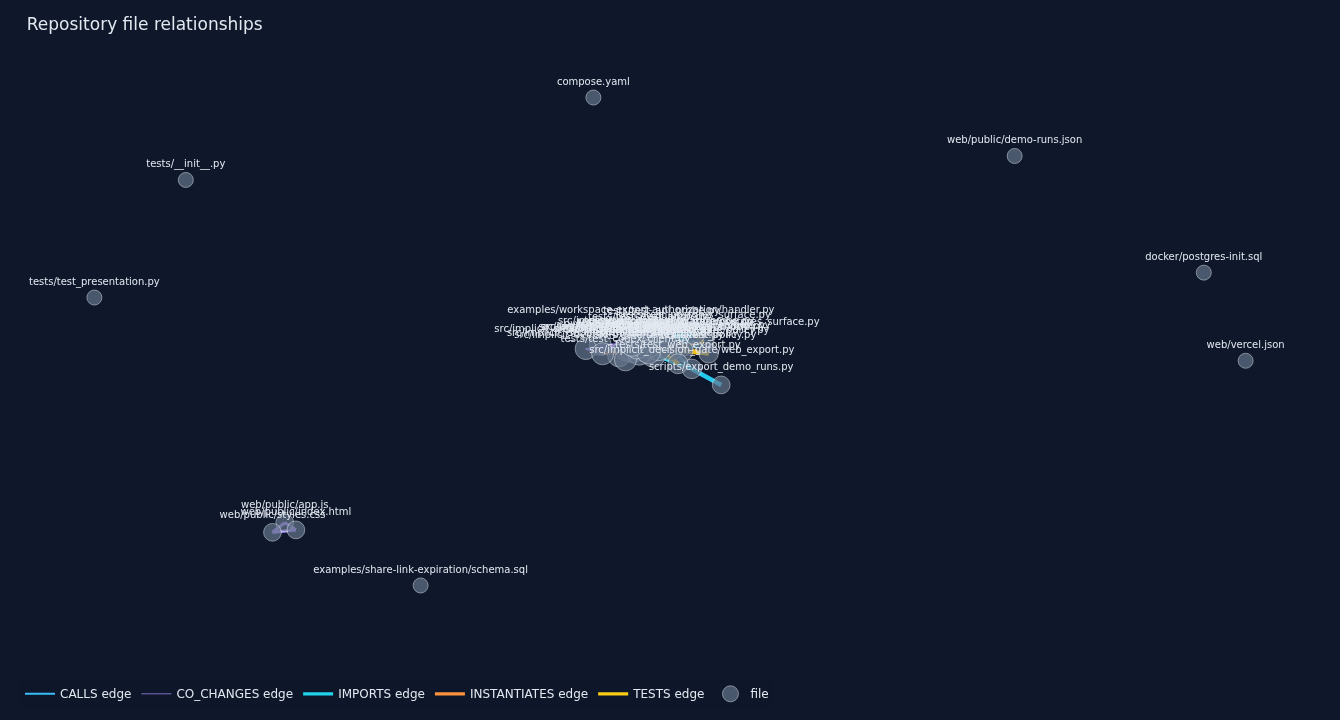

In [4]:
overview_figure = repository_overview_figure(knowledge)
display_graph(overview_figure, width=1340, height=720)

## Retrieve direct and related code

The search index combines word and identifier character TF-IDF features. Query expansion follows the strongest weighted paths from the direct anchors. Every related row includes its path so the result remains inspectable.

In [5]:
search_index = build_search_index(knowledge.nodes)
query = "where does a run pause for owner decisions and then resume?"
result = query_graph(knowledge, search_index, query)
result.relevant, result.related

(   rank                                            node_id  \
 0     1  symbol:src/implicit_decision_gate/gate.py::Fai...   
 1     2  symbol:src/implicit_decision_gate/gate.py::sho...   
 2     3  symbol:src/implicit_decision_gate/gate.py::Run...   
 3     4  symbol:src/implicit_decision_gate/orchestrator...   
 4     5  symbol:src/implicit_decision_gate/gate.py::ans...   
 5     6  symbol:src/implicit_decision_gate/gate.py::Run...   
 
                   node      kind  \
 0        FailureRecord     class   
 1         show_payload  function   
 2        RunStore.save    method   
 3  Orchestrator.resume    method   
 4         answer_owner  function   
 5        RunStore.load    method   
 
                                          location  direct_relevance  
 0          src/implicit_decision_gate/gate.py:142            0.0792  
 1          src/implicit_decision_gate/gate.py:415            0.0745  
 2          src/implicit_decision_gate/gate.py:211            0.0730  
 3  src/impl

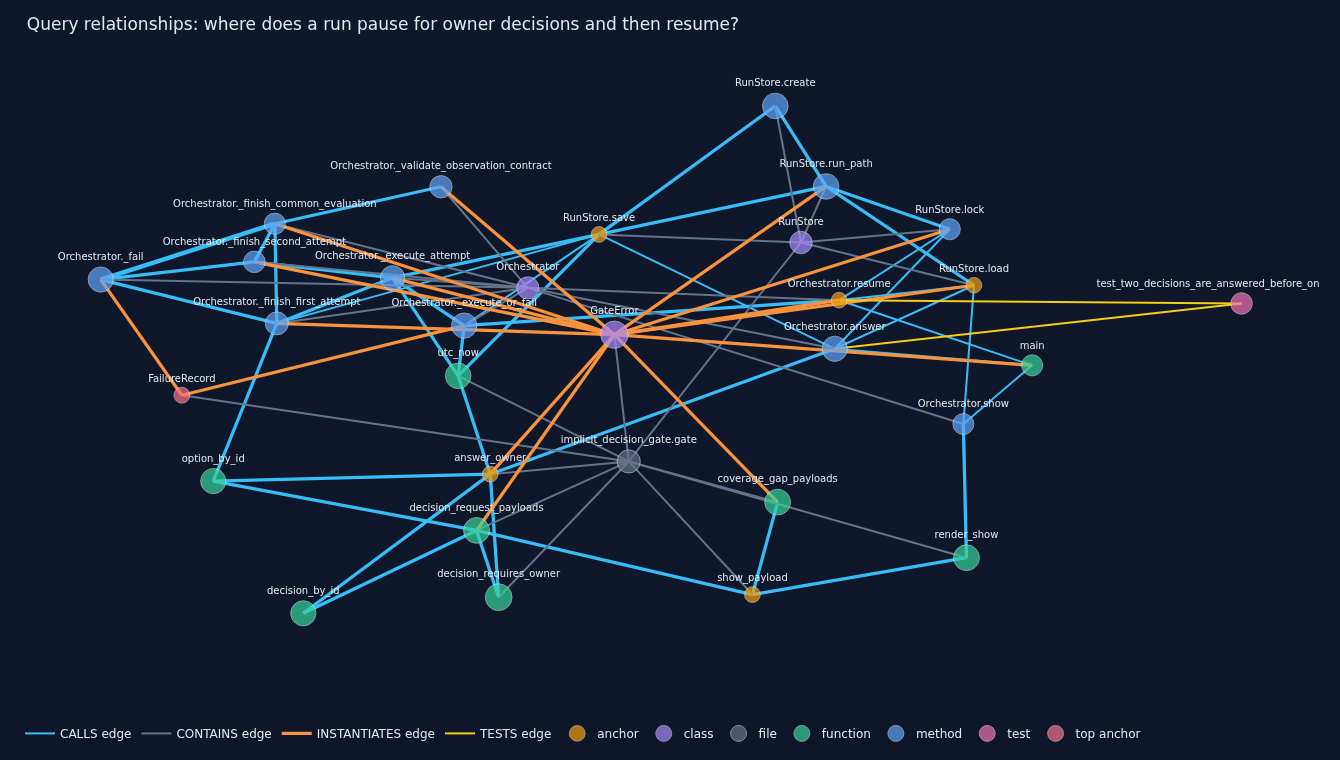

In [6]:
query_figure = query_result_figure(knowledge, result)
display_graph(query_figure, width=1340, height=760)

## Save deterministic artifacts

The JSON artifact is canonical and excludes the absolute repository root. The standalone HTML files include Plotly for offline viewing. Run this optional cell when you want files under the local `artifacts` directory.

In [7]:
artifact_directory = Path.cwd() / "artifacts"
write_graph_artifact(knowledge, artifact_directory / "knowledge_graph.json")
write_plotly_html(overview_figure, artifact_directory / "repository_overview.html")
write_plotly_html(query_figure, artifact_directory / "query_graph.html");